In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler,OneHotEncoder,RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv("/home/vivekananda-reddy/Desktop/Python/ML Project/data.csv")
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP


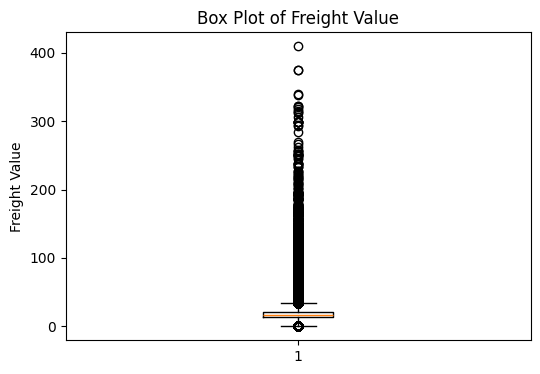

In [ ]:
#plotting the box plot for output freight value 
y = df["freight_value"]
plt.figure(figsize=(6,4))
plt.boxplot(y)
plt.title("Box Plot of Freight Value")
plt.ylabel("Freight Value")
plt.show()

In [5]:
#changing to date time format
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

#getting order month and order day
df["order_month"] = df["order_purchase_timestamp"].dt.month
df["order_weekday"] = df["order_purchase_timestamp"].dt.weekday

Text(0, 0.5, 'Count')

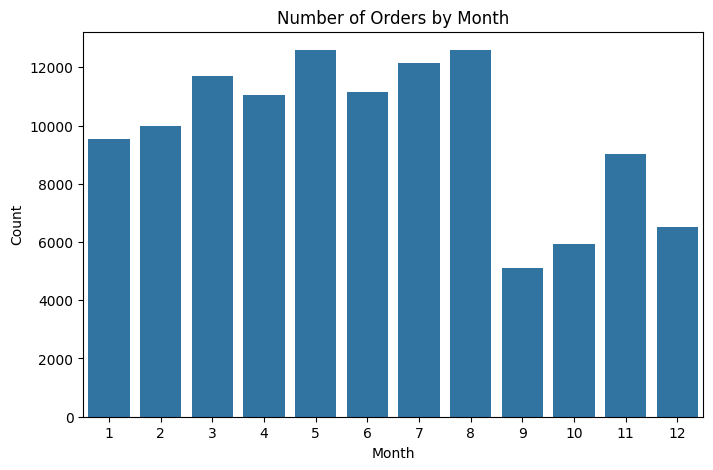

In [6]:
#plotting no of orders by month
plt.figure(figsize=(8,5))
sns.countplot(x="order_month", data=df)
plt.title("Number of Orders by Month")
plt.xlabel("Month")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

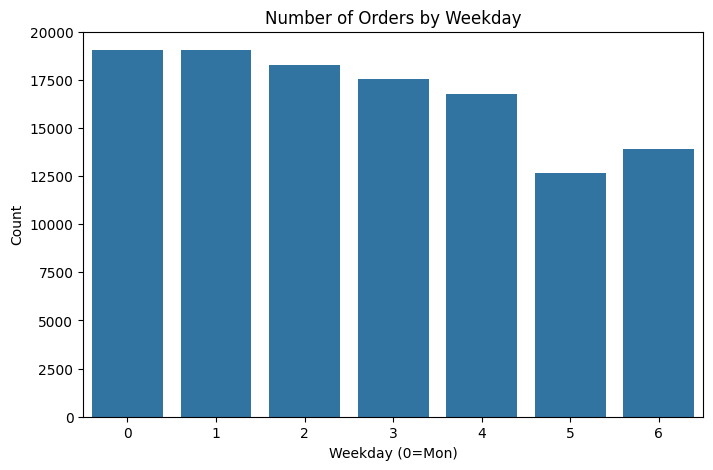

In [ ]:
#plotting no of orders by weekday
plt.figure(figsize=(8,5))
sns.countplot(x="order_weekday", data=df)
plt.title("Number of Orders by Weekday")
plt.xlabel("Weekday (0=Mon)")
plt.ylabel("Count")


In [8]:
#handling null values with medain
num_cols = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "product_photos_qty"
]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [9]:
#finding product volume
df['product_volume'] = df['product_length_cm']*df['product_height_cm']*df['product_width_cm']

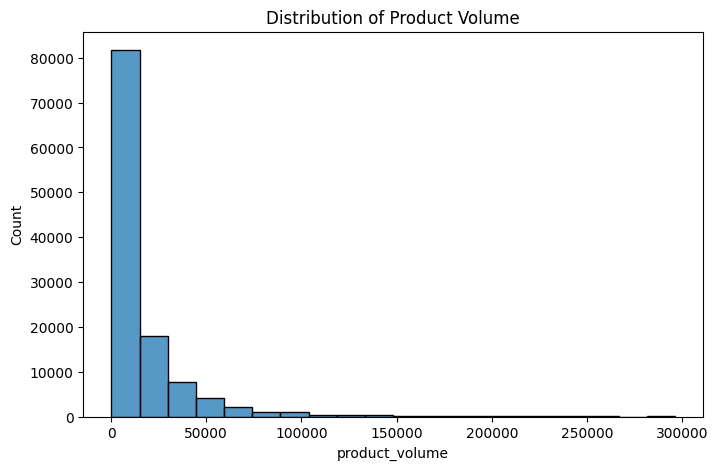

In [10]:
#plotting the volume graph
plt.figure(figsize=(8,5))
sns.histplot(df["product_volume"], bins=20)
plt.title("Distribution of Product Volume")
plt.show()

In [11]:
#finding the density
df['density'] = df['product_weight_g']/df['product_volume']

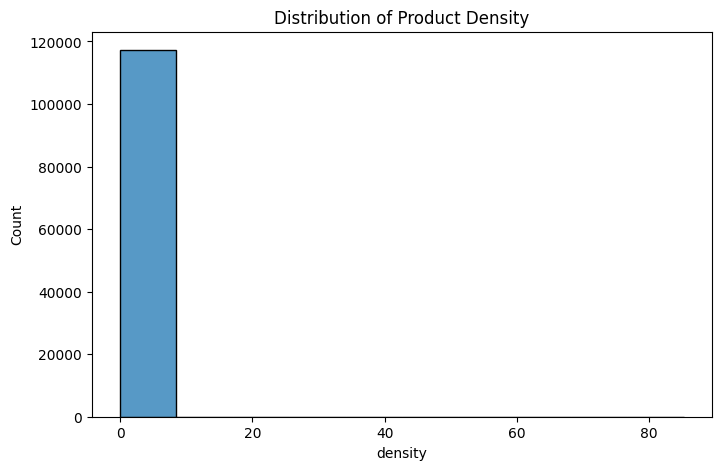

In [12]:
#plotting the density graph
plt.figure(figsize=(8,5))
sns.histplot(df["density"], bins=10)
plt.title("Distribution of Product Density")
plt.show()

In [13]:

#features for regression
features = [
    "product_weight_g",
    "product_volume",
    "density",
    "order_month",
    "order_weekday",
    "customer_state",
    "seller_state",
    "customer_city",
    "seller_city",
    "customer_zip_code_prefix",
    "seller_zip_code_prefix",
]

# df_model = df[features + ["total_order_value"]].dropna()



In [14]:
#removing outliers
Q1 = df["freight_value"].quantile(0.25)
Q3 = df["freight_value"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [15]:
df["freight_value"] = df["freight_value"].clip(lower, upper)

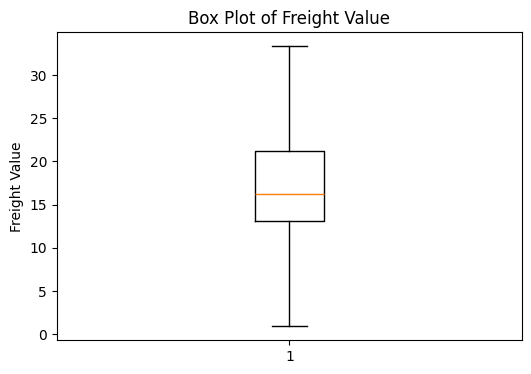

In [16]:
#box plot after removing outliers
y = df["freight_value"]

plt.figure(figsize=(6,4))
plt.boxplot(y)
plt.title("Box Plot of Freight Value")
plt.ylabel("Freight Value")
plt.show()

In [17]:
#splitting the data to test and train the model
X = df[features]
y = df["freight_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# X_train_sample = X_train.sample(20000, random_state=42)
# y_train_sample = y_train.loc[X_train_sample.index]

In [ ]:
#deviding the features as cat and num
categorical_cols = [
    "customer_state",
    "seller_state",
    "customer_city",
    "seller_city"
]


numerical_cols = [
    "product_weight_g",
    "product_volume",
    "density",
    "order_month",
    "order_weekday",
    "customer_zip_code_prefix",
    "seller_zip_code_prefix"
]


In [ ]:
#preprossesing those cat and num features with onehotencoder
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numerical_cols)
])

#setting the model pipeline
model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)


,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
#preidcting the output
y_pred = model.predict(X_test)

#finding metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.345581401638069
RMSE: 4.823706230399046
R2 Score: 0.5795130468377994


In [21]:
#preprossesing those cat and num features with onehotencoder

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numerical_cols)
])
#setting the model pipeline
model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100,random_state=42))
])
model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
y_pred = model.predict(X_test)

#metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.789531244726167
RMSE: 3.268536913128521
R2 Score: 0.8069376397026349
